<a href="https://colab.research.google.com/github/brunosolimoes/RL_CartPole_Qlearning/blob/lunar/LunarLander_V3_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium[box2d]
!pip install torch
!pip install matplotlib
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym

import numpy as np

import matplotlib.pyplot as plt

import random

from collections import deque

import torch

import torch.nn as nn

import torch.optim as optim

In [ ]:
env = gym.make(
    "LunarLander-v3"
)

print(
    env.observation_space
)

print(
    env.action_space
)

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Discrete(4)


In [ ]:
class DQN(nn.Module):

    def __init__(
        self,
        state_size,
        action_size
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                state_size,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                action_size
            )

        )

    def forward(
        self,
        x
    ):

        return self.net(x)

In [ ]:
state_size = 8

action_size = 4

model = DQN(
    state_size,
    action_size
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_fn = nn.MSELoss()

In [ ]:
memory = deque(
    maxlen=100000
)

In [ ]:
gamma=0.99

epsilon=1.0

epsilon_decay=0.995

epsilon_min=0.05

batch_size=64

episodes=500

In [ ]:
def choose_action(
    state
):

    if random.random()<epsilon:

        return env.action_space.sample()

    state_tensor=torch.FloatTensor(
        state
    ).unsqueeze(0)

    with torch.no_grad():

        q=model(
            state_tensor
        )

    return torch.argmax(
        q
    ).item()

In [ ]:
def train():

    if len(memory)<batch_size:

        return

    batch=random.sample(
        memory,
        batch_size
    )

    states=[]

    targets=[]

    for s,a,r,ns,d in batch:

        state_tensor=torch.FloatTensor(
            s
        )

        target=model(
            state_tensor
        ).detach().numpy()

        if d:

            target[a]=r

        else:

            next_q=torch.max(

                model(
                    torch.FloatTensor(
                        ns
                    )
                )

            ).item()

            target[a]=r+gamma*next_q

        states.append(s)

        targets.append(target)

    states=torch.FloatTensor(
        np.array(states)
    )

    targets=torch.FloatTensor(
        np.array(targets)
    )

    pred=model(
        states
    )

    loss=loss_fn(
        pred,
        targets
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

In [ ]:
rewards=[]

for ep in range(episodes):

    state,_=env.reset()

    done=False

    total=0

    while not done:

        action=choose_action(
            state
        )

        new_state,reward,terminated,truncated,_=env.step(
            action
        )

        done=terminated or truncated

        memory.append(

            (
                state,
                action,
                reward,
                new_state,
                done
            )

        )

        train()

        state=new_state

        total+=reward

    rewards.append(total)

    epsilon=max(

        epsilon_min,

        epsilon*epsilon_decay

    )

    if ep%10==0:

        print(
            ep,
            total
        )

0 -249.027571195483
10 -291.6497950529323
20 -198.0722616011998
30 -111.3423755977889
40 -129.6088678924581
50 -47.419753815194746
60 -84.8212308003503
70 -59.5435298082498
80 -99.74429399483104
90 -242.86230017955958
100 -123.93361548460666
110 -50.49561041272413
120 -66.65597169404064
130 -67.4937029471032
140 -75.6149372948607
150 -14.406381643912454
160 -61.304259589187545
170 8.804690200635434
180 -44.199943107920845
190 -45.57550842780833
200 21.540297584171366
210 -26.664853168014133
220 93.35746774969414
230 74.07321855861952
240 84.33021419317198
250 34.85458317372357
260 96.47264425604382
270 222.37314907939154
280 -34.54952921132377
290 142.24838278843583
300 -6.058038005221761
310 164.60311389798576
320 202.6237339028399
330 112.56697445877192
340 76.9403898915179
350 220.09721976327108
360 219.23492986064758
370 -308.14130916691977
380 24.06022118805224
390 61.4515292668525
400 -223.06816273104823
410 234.86134044734743
420 264.0394312829791
430 247.97749062292095
440 193.

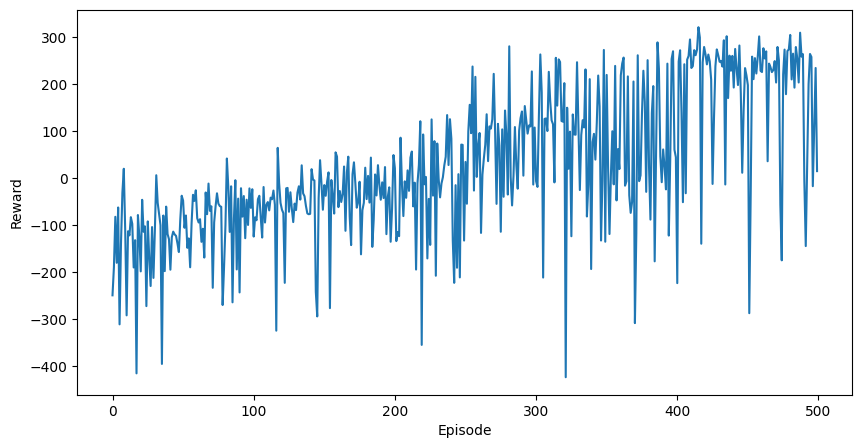

In [ ]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    rewards
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Reward"
)

plt.show()

In [ ]:
env = gym.make(

    "LunarLander-v3",

    render_mode="human"

)

state,_=env.reset()

done=False

while not done:

    state_tensor=torch.FloatTensor(
        state
    ).unsqueeze(0)

    with torch.no_grad():

        action=torch.argmax(

            model(
                state_tensor
            )

        ).item()

    state,_,terminated,truncated,_=env.step(
        action
    )

    done=terminated or truncated

env.close()